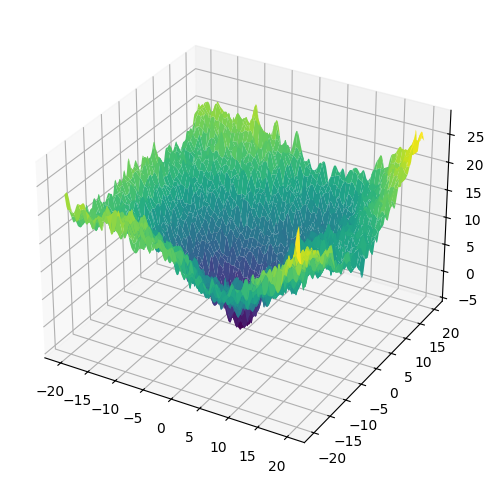

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from mpl_toolkits.mplot3d import Axes3D

# パラメータ設定
A = 5        # クレーターの深さ
sigma = 3    # クレーターの広がり
B = 0.8      # 傾斜の強さ
C = 6.0      # ノイズの強さ
D = 4        # うねりの強さ
alpha = 0.2  # うねりの周波数
flatten_scale = 1  # 縦方向スケーリング
noise_smooth = 1.8   # ノイズの平滑度（大きいと低周波）

# 格子状のx, y座標
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

# ノイズ生成 + 平滑化で周波数構造を加える
np.random.seed(0)
raw_noise = np.random.normal(scale=1.0, size=R.shape)
structured_noise = gaussian_filter(raw_noise, sigma=noise_smooth)

# 地形関数（D項追加 & 高さ圧縮）
Z = (
    -A * np.exp(-R**2 / (2 * sigma**2)) + 
    B * R +
    C * structured_noise +  # 空間的構造を持つノイズ
    D * np.sin(alpha * X) * np.cos(alpha * Y)
)
Z *= flatten_scale

# 描画
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
ax.set_zlim(Z.min(), Z.max())
plt.show()